In [8]:
# ===========================
# 1. Data Loading and Setup
# ===========================

import pandas as pd
import statsmodels.api as sm
import itertools
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, RidgeCV, Lasso, LassoCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report,recall_score, precision_score
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score, cross_val_predict, GridSearchCV, train_test_split

# Load the dataset
df = pd.read_csv('data.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [9]:
# ==========================================
# 2. Feature Selection and Preprocessing
# ==========================================

# Create train/validation split (80% train, 20% validation, stratified)
target = 'diagnosis'
y = df[target].map({'M': 1, 'B': 0})
X = df.drop(columns=[target])
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {X_train.shape[0]}, Validation samples: {X_val.shape[0]}")

# Randomly select 11 features for reduced model
np.random.seed(42)
selected_features = np.random.choice(X.columns, 11, replace=False)
X_reduced = X[selected_features]

def fit_linear_reg_reduced(feature_set):
    """
    Fit OLS regression on a subset of features and return model and metrics.
    """
    X_subset = sm.add_constant(X_reduced[list(feature_set)])
    model = sm.OLS(y, X_subset).fit()
    return {"model": model, "RSS": model.ssr, "R2": model.rsquared, 
            "Adj_R2": model.rsquared_adj, "BIC": model.bic, "AIC": model.aic}

# Find best model for each k
best_models_per_k_reduced = []
for k in range(1, len(X_reduced.columns) + 1):
    best_rss = float("inf")
    best_subset_for_k = None
    for combo in itertools.combinations(X_reduced.columns, k):
        results = fit_linear_reg_reduced(combo)
        if results["RSS"] < best_rss:
            best_rss = results["RSS"]
            best_subset_for_k = results
    best_models_per_k_reduced.append(best_subset_for_k)

models_df_reduced = pd.DataFrame(best_models_per_k_reduced)
best_overall_model_reduced = models_df_reduced.loc[models_df_reduced['BIC'].idxmin()]
print(f"Best subset features (reduced): {best_overall_model_reduced['model'].model.exog_names}")

Training samples: 455, Validation samples: 114
Best subset features (reduced): ['const', 'concavity_worst', 'smoothness_se', 'perimeter_worst', 'concavity_se', 'symmetry_worst', 'area_worst', 'texture_se']


In [10]:
# ==========================================
# 3. Forward Stepwise Selection
# ==========================================

def forward_stepwise_selection(X, y):
    """
    Perform forward stepwise selection for linear regression.
    Returns a DataFrame with the best model at each step.
    """
    features = []
    models_sequence = []
    remaining_features = list(X.columns)
    for k in range(len(X.columns)):
        best_rss = float('inf')
        best_feature = None
        best_model = None
        for combo in remaining_features:
            X_subset = sm.add_constant(X[features + [combo]])
            model = sm.OLS(y, X_subset).fit()
            if model.ssr < best_rss:
                best_rss = model.ssr
                best_feature = combo
                best_model = model
        features.append(best_feature)
        remaining_features.remove(best_feature)
        models_sequence.append({'k': len(features), 'model': best_model, 'features': list(features)})
    return pd.DataFrame(models_sequence)

# Run forward selection
fwd_results = forward_stepwise_selection(X, y)
fwd_metrics = pd.DataFrame({
    'Num_Predictors': fwd_results['k'],
    'BIC': [m.bic for m in fwd_results['model']],
    'Adj_R2': [m.rsquared_adj for m in fwd_results['model']]
})
print("Forward Stepwise Selection Results:")
print(fwd_metrics.sort_values(by='BIC', ascending=True))

Forward Stepwise Selection Results:
    Num_Predictors         BIC    Adj_R2
10              11   42.003531  0.759456
12              13   43.702551  0.763207
11              12   44.024996  0.760847
13              14   45.691860  0.764588
9               10   46.658804  0.755200
8                9   48.526198  0.752086
14              15   49.962536  0.765020
7                8   51.951025  0.748244
15              16   53.879263  0.765596
6                7   57.220036  0.743511
5                6   58.332647  0.740590
16              17   58.534684  0.765867
17              18   64.253494  0.765698
4                5   69.381249  0.733013
18              19   70.147001  0.765457
19              20   76.097972  0.765191
20              21   82.038432  0.764929
21              22   87.973887  0.764667
3                4   89.648772  0.720726
22              23   93.691645  0.764495
23              24   99.560325  0.764259
2                3  102.031432  0.711893
24              25  1

In [11]:
# ==========================================
# 4. Backward Stepwise Selection
# ==========================================

def backward_stepwise_selection(X, y):
    """
    Perform backward stepwise selection for linear regression.
    Returns a DataFrame with the best model at each step.
    """
    features = list(X.columns)
    models_sequence = []
    while len(features) > 0:
        X_subset = sm.add_constant(X[features])
        current_model = sm.OLS(y, X_subset).fit()
        models_sequence.append({'k': len(features), 'model': current_model, 'features': list(features)})
        if len(features) == 1:
            break
        best_rss = float('inf')
        feature_to_remove = None
        for feature in features:
            subset = [f for f in features if f != feature]
            X_temp = sm.add_constant(X[subset])
            model = sm.OLS(y, X_temp).fit()
            if model.ssr < best_rss:
                best_rss = model.ssr
                feature_to_remove = feature
        features.remove(feature_to_remove)
    return pd.DataFrame(models_sequence)

# Run backward selection
bwd_results = backward_stepwise_selection(X, y)
bwd_metrics = pd.DataFrame({
    'Num_Predictors': bwd_results['k'],
    'BIC': [m.bic for m in bwd_results['model']],
    'AIC': [m.aic for m in bwd_results['model']]
})
print("\nBackward Stepwise Selection Results:")
print(bwd_metrics.sort_values(by='BIC', ascending=True))


Backward Stepwise Selection Results:
    Num_Predictors         BIC         AIC
19              12   35.503456  -20.966989
20              11   35.922381  -16.204184
18              13   36.797518  -24.016808
17              14   40.683455  -24.474751
21              10   43.123747   -4.658938
16              15   46.334499  -23.167588
22               9   50.509441    7.070637
15              16   51.805568  -22.040400
14              17   57.575846  -20.614002
23               8   58.538799   19.443875
13              18   63.345790  -19.187938
12              19   69.093424  -17.784185
24               7   69.689667   34.938624
25               6   70.608783   40.201620
11              20   74.903668  -16.317821
10              21   80.944195  -14.621174
26               5   81.380560   55.317277
9               22   86.874536  -13.034714
8               23   93.065276  -11.187854
7               24   99.153366   -9.443645
27               4  102.175121   80.455719
6               

Optimal Lambda (λ): 2.205130739903041


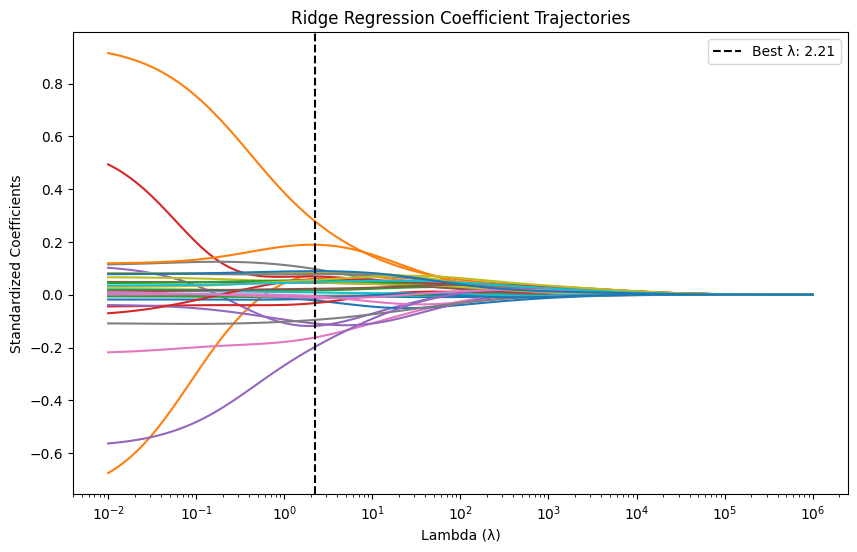

In [12]:
# ==========================================
# 5. Ridge Regression with Cross-Validation
# ==========================================

# 1. Standardize predictors
# Standardizing ensures the penalty is applied fairly across all variables.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Define a range of lambda (alpha in sklearn) values for regularization strength
lambdas = 10**np.linspace(6, -2, 100)

# 3. Use RidgeCV to automatically find the best lambda using cross-validation
ridge_cv = RidgeCV(alphas=lambdas, scoring='neg_mean_squared_error', cv=10)
ridge_cv.fit(X_scaled, y)
best_lambda = ridge_cv.alpha_

print(f"Optimal Lambda (λ): {best_lambda}")

# 4. Fit the final Ridge model with the best lambda
final_model = Ridge(alpha=best_lambda)
final_model.fit(X_scaled, y)

# 5. Plot the coefficient trajectories as lambda changes
coefs = []
for l in lambdas:
    ridge = Ridge(alpha=l)
    ridge.fit(X_scaled, y)
    coefs.append(ridge.coef_)

plt.figure(figsize=(10, 6))
ax = plt.gca()
ax.plot(lambdas, coefs)
ax.set_xscale('log')  # Lambda is typically viewed on a log scale
plt.xlabel('Lambda (λ)')
plt.ylabel('Standardized Coefficients')
plt.title('Ridge Regression Coefficient Trajectories')
plt.axvline(x=best_lambda, color='black', linestyle='--', label=f'Best λ: {best_lambda:.2f}')
plt.legend()
plt.show()

Optimal Lambda (λ): 0.017475284000076828
Variables selected by Lasso: ['texture_mean', 'concave points_mean', 'radius_se', 'radius_worst', 'texture_worst', 'smoothness_worst', 'concave points_worst', 'symmetry_worst']


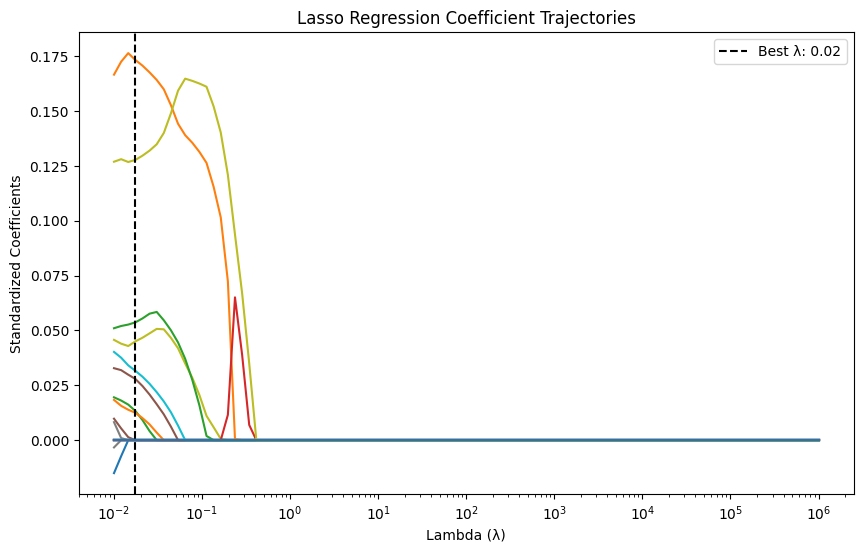

In [13]:
# ==========================================
# 6. Lasso Regression with Cross-Validation
# ==========================================

# 1. Standardize predictors
# Lasso is scale-sensitive; standardization ensures the penalty is applied uniformly.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Define a range of lambda (alpha in sklearn) values for regularization strength
lambdas = 10**np.linspace(6, -2, 100)

# 3. Use LassoCV to automatically find the best lambda using cross-validation
# LassoCV performs k-fold CV to select the optimal regularization parameter.
lasso_cv = LassoCV(alphas=lambdas, cv=10, max_iter=10000)
lasso_cv.fit(X_scaled, y)
best_lambda = lasso_cv.alpha_

print(f"Optimal Lambda (λ): {best_lambda}")

# 4. Fit the final Lasso model with the best lambda
final_lasso = Lasso(alpha=best_lambda)
final_lasso.fit(X_scaled, y)

# 5. Identify selected variables (coefficients != 0)
selected_features = X.columns[final_lasso.coef_ != 0]
print(f"Variables selected by Lasso: {list(selected_features)}")

# 6. Plot the coefficient trajectories as lambda changes
coefs = []
for l in lambdas:
    lasso = Lasso(alpha=l, max_iter=10000)
    lasso.fit(X_scaled, y)
    coefs.append(lasso.coef_)

plt.figure(figsize=(10, 6))
ax = plt.gca()
ax.plot(lambdas, coefs)
ax.set_xscale('log')
plt.xlabel('Lambda (λ)')
plt.ylabel('Standardized Coefficients')
plt.title('Lasso Regression Coefficient Trajectories')
plt.axvline(x=best_lambda, color='black', linestyle='--', label=f'Best λ: {best_lambda:.2f}')
plt.legend()
plt.show()

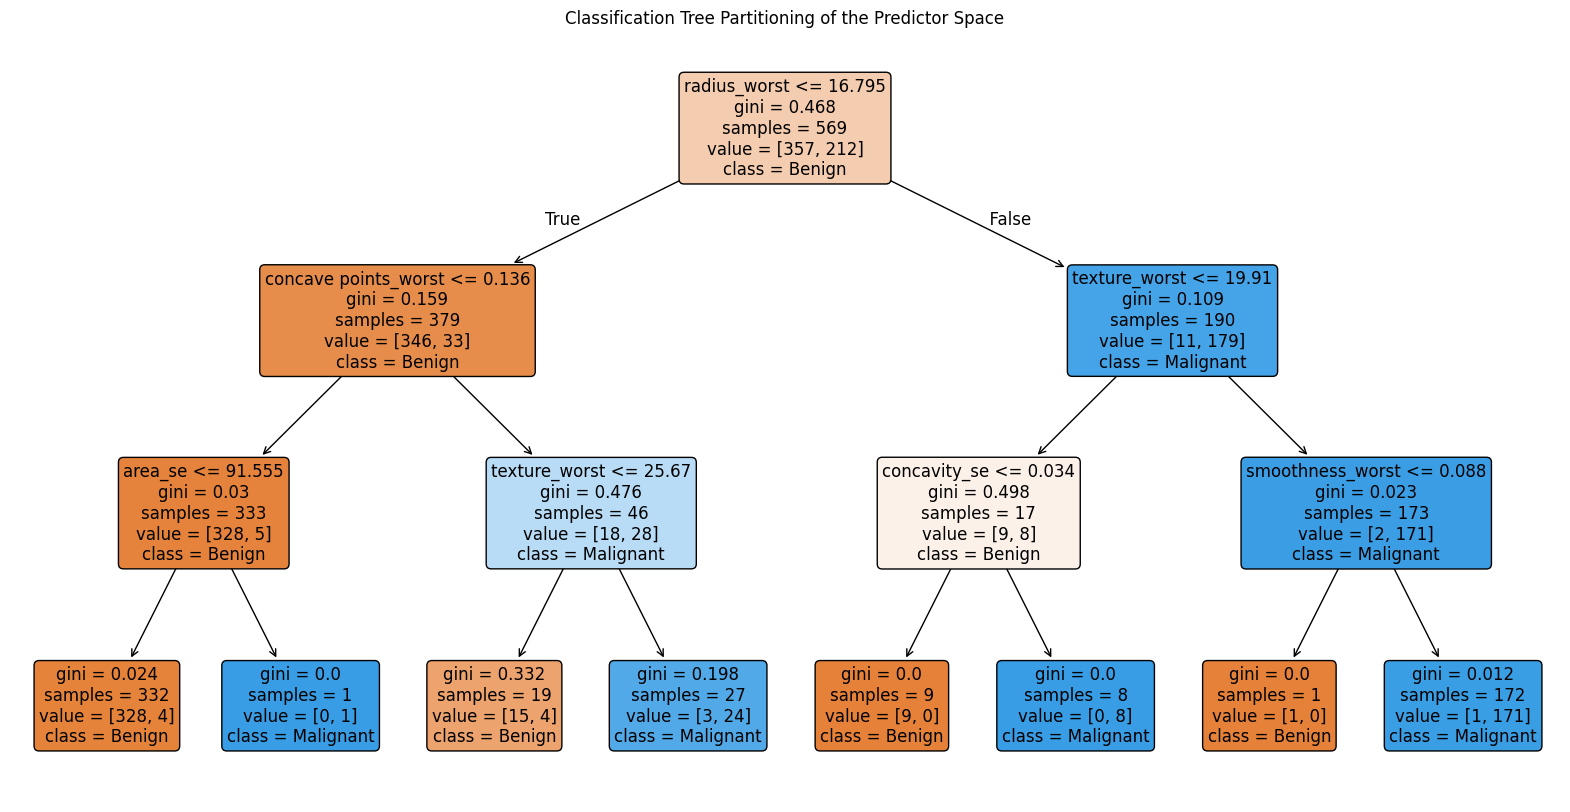

In [14]:
# ==========================================
# 7. Decision Tree: Training and Visualization
# ==========================================

# 1. Initialize the Decision Tree Classifier
# max_depth=3 limits the depth to avoid overfitting and improve interpretability.
clf_tree = DecisionTreeClassifier(max_depth=3, random_state=42)

# 2. Fit the model to the entire dataset
clf_tree.fit(X, y)

# 3. Visualize the trained decision tree
plt.figure(figsize=(20, 10))
plot_tree(
    clf_tree, 
    feature_names=X.columns, 
    class_names=['Benign', 'Malignant'],
    filled=True, 
    rounded=True, 
    fontsize=12
)
plt.title("Classification Tree Partitioning of the Predictor Space")
plt.show()

In [15]:
# ==========================================
# 7b. Decision Tree: Training Metrics on Full Data
# ==========================================

# Predict on the training data using the fitted decision tree
y_pred = clf_tree.predict(X)

# Calculate and display standard classification metrics
accuracy = accuracy_score(y, y_pred)  # Overall accuracy
precision = precision_score(y, y_pred)  # Precision for the positive class
recall = recall_score(y, y_pred)  # Recall for the positive class
cm = confusion_matrix(y, y_pred)  # Confusion matrix
report = classification_report(y, y_pred, target_names=['Benign', 'Malignant'], digits=4)  # Detailed report

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print("\nConfusion Matrix:")
print(cm)
print("\nClassification Report:")
print(report)

Accuracy:  0.9789
Precision: 0.9808
Recall:    0.9623

Confusion Matrix:
[[353   4]
 [  8 204]]

Classification Report:
              precision    recall  f1-score   support

      Benign     0.9778    0.9888    0.9833       357
   Malignant     0.9808    0.9623    0.9714       212

    accuracy                         0.9789       569
   macro avg     0.9793    0.9755    0.9774       569
weighted avg     0.9789    0.9789    0.9789       569



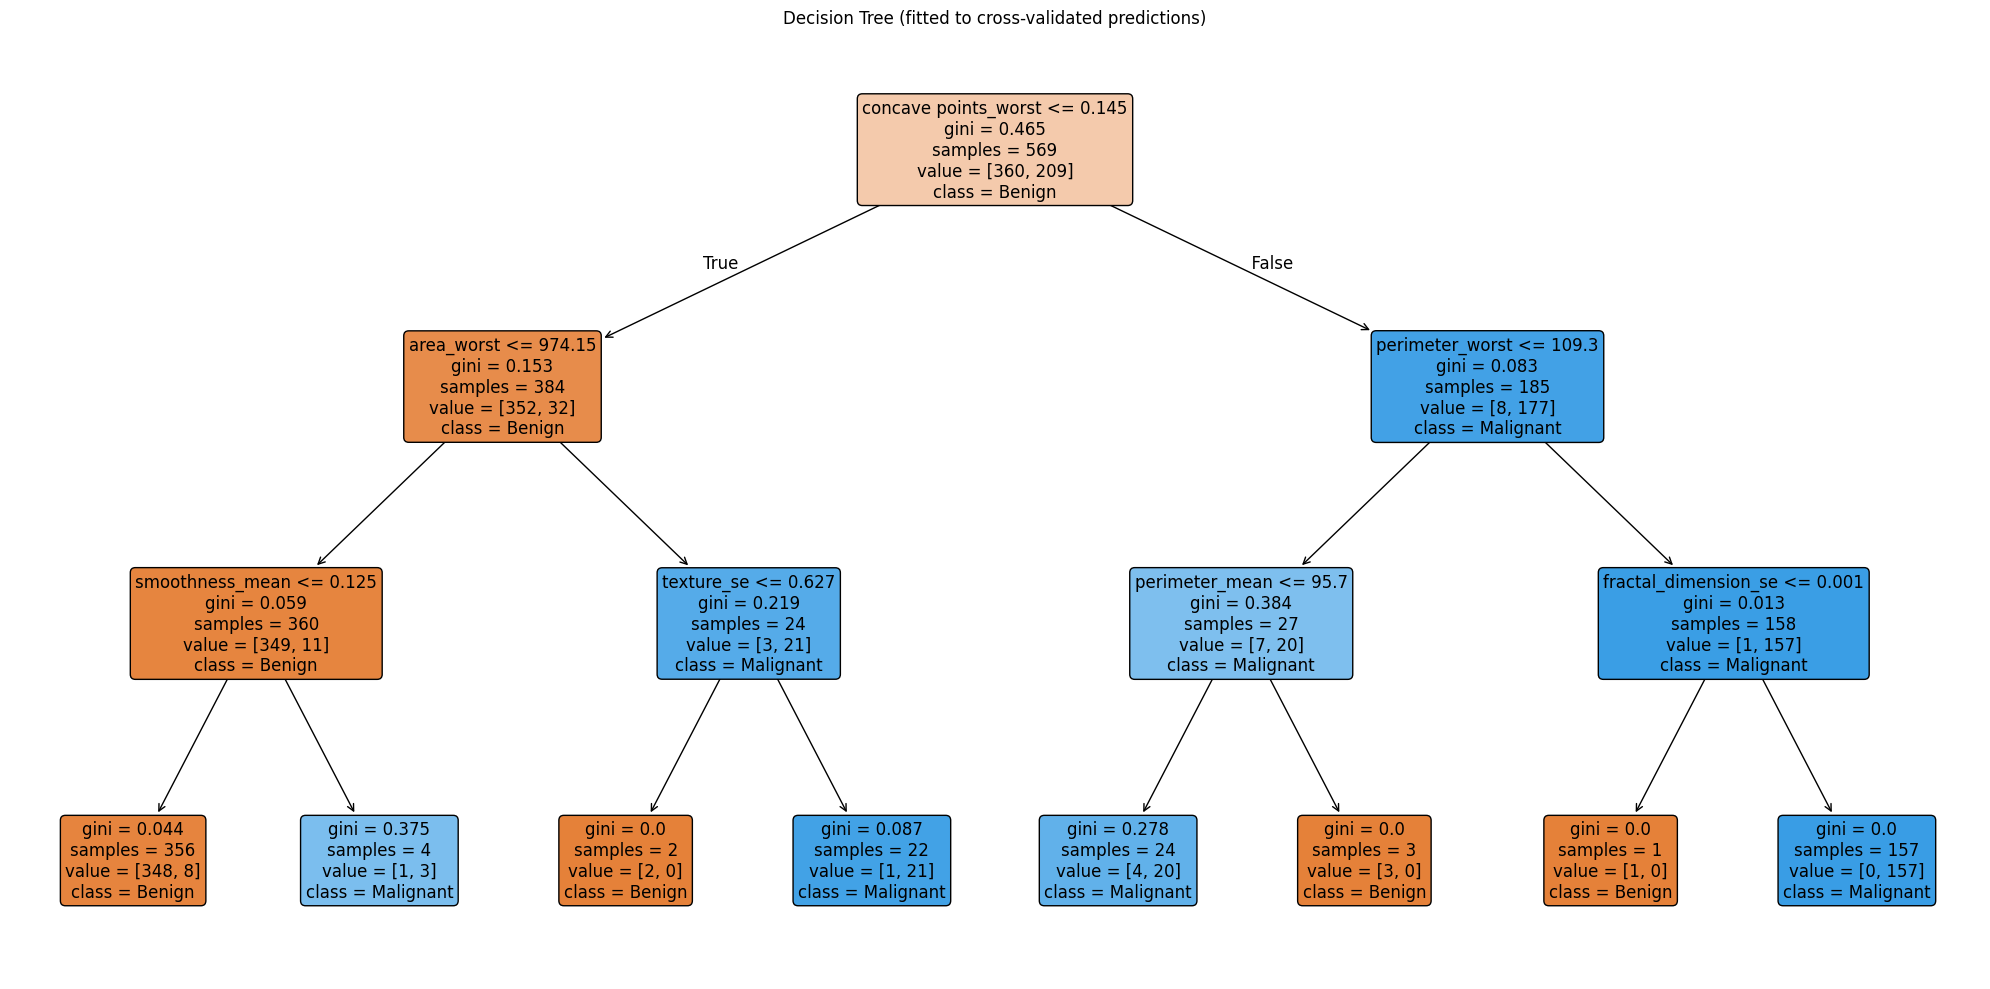

Decision Tree Classifier Cross-Validated Results:
Accuracy:  0.9174
Precision: 0.8947
Recall:    0.8821

Confusion Matrix:
[[335  22]
 [ 25 187]]

Classification Report:
              precision    recall  f1-score   support

      Benign     0.9306    0.9384    0.9344       357
   Malignant     0.8947    0.8821    0.8884       212

    accuracy                         0.9174       569
   macro avg     0.9126    0.9102    0.9114       569
weighted avg     0.9172    0.9174    0.9173       569



In [ ]:
# ==========================================
# 8. Decision Tree: Cross-Validated Performance
# ==========================================

# 1. Initialize the Decision Tree Classifier (same parameters as before)
clf_tree_cv = DecisionTreeClassifier(max_depth=3, random_state=42)

# 2. Obtain cross-validated predictions (5-fold CV)
y_pred_tree_cv = cross_val_predict(clf_tree_cv, X, y, cv=5)

# 3. Calculate metrics based on cross-validated predictions
accuracy_tree_cv = accuracy_score(y, y_pred_tree_cv)
precision_tree_cv = precision_score(y, y_pred_tree_cv)
recall_tree_cv = recall_score(y, y_pred_tree_cv)
cm_tree_cv = confusion_matrix(y, y_pred_tree_cv)
report_tree_cv = classification_report(y, y_pred_tree_cv, target_names=['Benign', 'Malignant'], digits=4)
# ensure y_pred_tree_cv exists (from the CV cell)
# Fit a shallow tree to the CV-predicted labels to visualize the CV decision structure
clf_tree_from_cv = DecisionTreeClassifier(max_depth=3, random_state=42)
clf_tree_from_cv.fit(X, y_pred_tree_cv)

# plot the tree fitted to the CV predictions
plt.figure(figsize=(20, 10))
plot_tree(
    clf_tree_from_cv,
    feature_names=X.columns,
    class_names=['Benign', 'Malignant'],
    filled=True,
    rounded=True,
    fontsize=12
)
plt.title("Decision Tree (fitted to cross-validated predictions)")
plt.tight_layout()
plt.show()
# 4. Display results
print("Decision Tree Classifier Cross-Validated Results:")
print(f"Accuracy:  {accuracy_tree_cv:.4f}")
print(f"Precision: {precision_tree_cv:.4f}")
print(f"Recall:    {recall_tree_cv:.4f}")
print("\nConfusion Matrix:")
print(cm_tree_cv)
print("\nClassification Report:")
print(report_tree_cv)

In [17]:
# ==========================================
# 9. Bagging Classifier: Cross-Validated Performance
# ==========================================

# 1. Initialize the Bagging Classifier with Decision Trees as base estimators
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    random_state=42
)

# 2. Obtain cross-validated predictions (5-fold CV)
y_pred_bag_cv = cross_val_predict(bagging, X, y, cv=5)

# 3. Calculate metrics based on cross-validated predictions
accuracy_bag = accuracy_score(y, y_pred_bag_cv)
precision_bag = precision_score(y, y_pred_bag_cv)
recall_bag = recall_score(y, y_pred_bag_cv)
cm_bag = confusion_matrix(y, y_pred_bag_cv)
report_bag = classification_report(y, y_pred_bag_cv, target_names=['Benign', 'Malignant'], digits=4)

# 4. Display results
print("Bagging Classifier Cross-Validated Results:")
print(f"Accuracy:  {accuracy_bag:.4f}")
print(f"Precision: {precision_bag:.4f}")
print(f"Recall:    {recall_bag:.4f}")
print("\nConfusion Matrix:")
print(cm_bag)
print("\nClassification Report:")
print(report_bag)

# 5. Interpretation
print(
    "\nInterpretation:\n"
    "Cross-validation provides a better estimate of the model's generalization performance and helps avoid overfitting. "
    "Compare the cross-validated accuracy with the training accuracy: if training accuracy is much higher, overfitting may be present. "
    "Bagging reduces variance and typically improves stability and accuracy compared to a single tree."
)

Bagging Classifier Cross-Validated Results:
Accuracy:  0.9561
Precision: 0.9474
Recall:    0.9340

Confusion Matrix:
[[346  11]
 [ 14 198]]

Classification Report:
              precision    recall  f1-score   support

      Benign     0.9611    0.9692    0.9651       357
   Malignant     0.9474    0.9340    0.9406       212

    accuracy                         0.9561       569
   macro avg     0.9542    0.9516    0.9529       569
weighted avg     0.9560    0.9561    0.9560       569


Interpretation:
Cross-validation provides a better estimate of the model's generalization performance and helps avoid overfitting. Compare the cross-validated accuracy with the training accuracy: if training accuracy is much higher, overfitting may be present. Bagging reduces variance and typically improves stability and accuracy compared to a single tree.


In [18]:
# ==========================================
# 10. Random Forest: Cross-Validated Performance
# ==========================================

# 1. Cross-validation on training set
rf = RandomForestClassifier(n_estimators=100, max_features='sqrt', random_state=42)
cv_scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='accuracy')
print("CV accuracy (train set):", np.mean(cv_scores))

# 2. Fit on full training set
rf.fit(X_train, y_train)

# 3. Evaluate on validation set
y_pred_val = rf.predict(X_val)
print("Validation accuracy:", accuracy_score(y_val, y_pred_val))


# 3. Calculate metrics based on cross-validated predictions
accuracy_rf = accuracy_score(y_val, y_pred_val)
precision_rf = precision_score(y_val, y_pred_val)
recall_rf = recall_score(y_val, y_pred_val)
cm_rf = confusion_matrix(y_val, y_pred_val)
report_rf = classification_report(y_val, y_pred_val, target_names=['Benign', 'Malignant'], digits=4)

# 4. Display results
print("\nRandom Forest Cross-Validated Results:")
print(f"Accuracy:  {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall:    {recall_rf:.4f}")
print("\nConfusion Matrix:")
print(cm_rf)
print("\nClassification Report:")
print(report_rf)

# 5. Interpretation
print(
    "\nInterpretation:\n"
    "Random Forests further reduce variance compared to bagging by also randomly selecting features for each split, "
    "which decorrelates the trees and often improves generalization. "
    "Compare the cross-validated accuracy and training accuracy to assess overfitting. "
    "Random Forests typically outperform single trees and bagging, especially when the number of predictors is large."
)

CV accuracy (train set): 0.9560439560439562
Validation accuracy: 0.956140350877193

Random Forest Cross-Validated Results:
Accuracy:  0.9561
Precision: 1.0000
Recall:    0.8810

Confusion Matrix:
[[72  0]
 [ 5 37]]

Classification Report:
              precision    recall  f1-score   support

      Benign     0.9351    1.0000    0.9664        72
   Malignant     1.0000    0.8810    0.9367        42

    accuracy                         0.9561       114
   macro avg     0.9675    0.9405    0.9516       114
weighted avg     0.9590    0.9561    0.9555       114


Interpretation:
Random Forests further reduce variance compared to bagging by also randomly selecting features for each split, which decorrelates the trees and often improves generalization. Compare the cross-validated accuracy and training accuracy to assess overfitting. Random Forests typically outperform single trees and bagging, especially when the number of predictors is large.


In [19]:
# ==========================================
# 11. Gradient Boosting: Cross-Validated Performance
# ==========================================

# 1. Initialize the Gradient Boosting Classifier
gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

# 2. Obtain cross-validated predictions (5-fold CV)
y_pred_gb_cv = cross_val_predict(gb, X, y, cv=5)

# 3. Calculate metrics based on cross-validated predictions
accuracy_gb = accuracy_score(y, y_pred_gb_cv)
precision_gb = precision_score(y, y_pred_gb_cv)
recall_gb = recall_score(y, y_pred_gb_cv)
cm_gb = confusion_matrix(y, y_pred_gb_cv)
report_gb = classification_report(y, y_pred_gb_cv, target_names=['Benign', 'Malignant'], digits=4)

# 4. Display results
print("\nGradient Boosting Cross-Validated Results:")
print(f"Accuracy:  {accuracy_gb:.4f}")
print(f"Precision: {precision_gb:.4f}")
print(f"Recall:    {recall_gb:.4f}")
print("\nConfusion Matrix:")
print(cm_gb)
print("\nClassification Report:")
print(report_gb)

# 5. Interpretation
print(
    "\nInterpretation:\n"
    "Boosting builds an ensemble of weak learners (shallow trees), where each new tree focuses on correcting the errors of the previous ones. "
    "It often achieves higher accuracy than bagging and random forests, but can be more sensitive to overfitting if not tuned properly. "
    "Compare the cross-validated accuracy and training accuracy to assess generalization. "
    "If training accuracy is much higher than cross-validated accuracy, the model may be overfitting."
)


Gradient Boosting Cross-Validated Results:
Accuracy:  0.9543
Precision: 0.9471
Recall:    0.9292

Confusion Matrix:
[[346  11]
 [ 15 197]]

Classification Report:
              precision    recall  f1-score   support

      Benign     0.9584    0.9692    0.9638       357
   Malignant     0.9471    0.9292    0.9381       212

    accuracy                         0.9543       569
   macro avg     0.9528    0.9492    0.9509       569
weighted avg     0.9542    0.9543    0.9542       569


Interpretation:
Boosting builds an ensemble of weak learners (shallow trees), where each new tree focuses on correcting the errors of the previous ones. It often achieves higher accuracy than bagging and random forests, but can be more sensitive to overfitting if not tuned properly. Compare the cross-validated accuracy and training accuracy to assess generalization. If training accuracy is much higher than cross-validated accuracy, the model may be overfitting.


Model Comparison (higher is better):
                      Model  Accuracy  Precision  Recall
0       Classification Tree    0.9789     0.9808  0.9623
1  Classification Tree (CV)    0.9174     0.8947  0.8821
2              Bagging (CV)    0.9561     0.9474  0.9340
3        Random Forest (CV)    0.9561     1.0000  0.8810
4             Boosting (CV)    0.9543     0.9471  0.9292


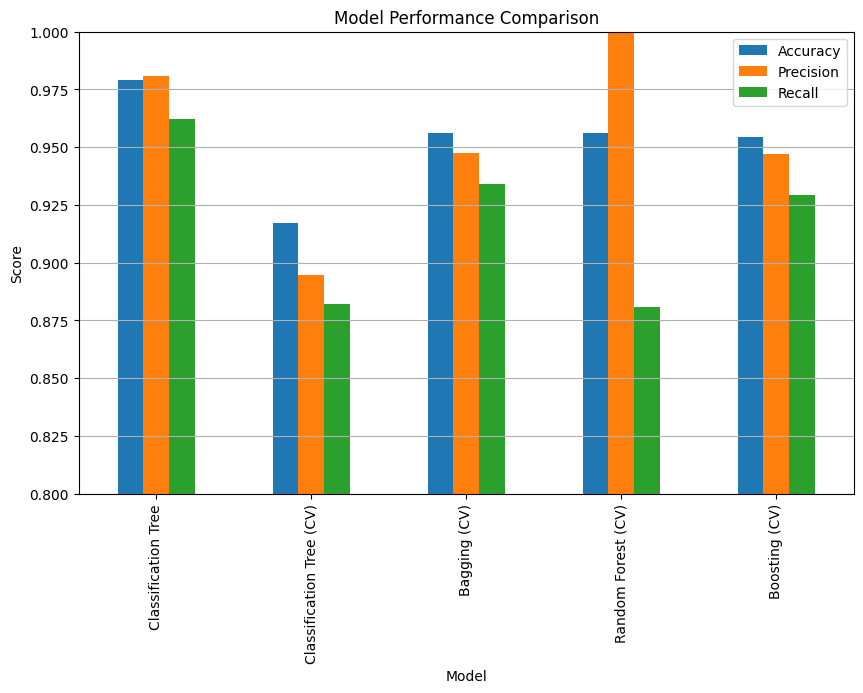

In [20]:
# ==========================================
# 12. Model Comparison: Summary Table and Plot
# ==========================================

# Collect metrics for each model
results = {
    "Model": [
        "Classification Tree",
        "Classification Tree (CV)",
        "Bagging (CV)",
        "Random Forest (CV)",
        "Boosting (CV)"
    ],
    "Accuracy": [
        accuracy,           # from the classification tree cell
        accuracy_tree_cv,   # from the cross-validated tree cell
        accuracy_bag,       # from Bagging (CV)
        accuracy_rf,        # from Random Forest (CV)
        accuracy_gb         # from Boosting (CV)
    ],
    "Precision": [
        precision,          # from the classification tree cell
        precision_tree_cv,  # from the cross-validated tree cell
        precision_bag,      # from Bagging (CV)
        precision_rf,       # from Random Forest (CV)
        precision_gb        # from Boosting (CV)
    ],
    "Recall": [
        recall,             # from the classification tree cell
        recall_tree_cv,     # from the cross-validated tree cell
        recall_bag,         # from Bagging (CV)
        recall_rf,          # from Random Forest (CV)
        recall_gb           # from Boosting (CV)
    ]
}

results_df = pd.DataFrame(results)
print("Model Comparison (higher is better):")
print(results_df.round(4))

# Optional: visualize as a bar plot
results_df.set_index("Model")[["Accuracy", "Precision", "Recall"]].plot.bar(figsize=(10,6))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0.8, 1.0)
plt.grid(axis='y')
plt.show()

In [21]:
# ==========================================
# 13. Hyperparameter Tuning for Recall (Random Forest)
# ==========================================

# Define parameter grid for tuning
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [2, 3, 5, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize Random Forest
rf = RandomForestClassifier(random_state=42)

# GridSearchCV to maximize recall
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='recall',
    cv=5,
    n_jobs=-1
)

# Fit grid search
grid_search.fit(X, y)

print("Best parameters for recall:", grid_search.best_params_)
print("Best cross-validated recall:", grid_search.best_score_)

Best parameters for recall: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 50}
Best cross-validated recall: 0.9438538205980066


In [22]:
# ==========================================
# 14. Adjust Classification Threshold for Higher Recall
# ==========================================

# Use the best estimator from grid search
rf_best = grid_search.best_estimator_

# Get predicted probabilities
y_proba = rf_best.predict_proba(X)[:, 1]

# Lower threshold to increase recall
threshold = 0.3
y_pred_thresh = (y_proba > threshold).astype(int)

# Calculate recall and precision at this threshold
recall_thresh = recall_score(y, y_pred_thresh)
precision_thresh = precision_score(y, y_pred_thresh)

print(f"Recall at threshold {threshold}: {recall_thresh:.4f}")
print(f"Precision at threshold {threshold}: {precision_thresh:.4f}")

Recall at threshold 0.3: 1.0000
Precision at threshold 0.3: 0.9381


In [23]:
# ==========================================
# 12. Use Class Weights to Penalize False Negatives
# ==========================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

# Initialize Random Forest with balanced class weights
rf_weighted = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)

# Cross-validated recall score
recall_weighted = cross_val_score(rf_weighted, X, y, cv=5, scoring='recall')

print("Cross-validated recall with class_weight='balanced':", recall_weighted.mean())

Cross-validated recall with class_weight='balanced': 0.9249169435215947
